In [1]:
import numpy as np
import pandas as pd

# data

In [40]:
# TODO data train test target

df_tr = pd.read_csv('D:\Eduson_data\sibur_train_features.csv')

df_ts = pd.read_csv('D:\Eduson_data\sibur_test_features.csv')

df_tg = pd.read_csv('D:\Eduson_data\sibur_train_targets.csv')

df_sb = pd.read_csv('D:\Eduson_data\sibur_sample_submission.csv')

print(df_tr.columns)
print(df_ts.columns)



# data[data.index.day == 9]

# data.index.dtype

Index(['timestamp', 'A_rate', 'A_CH4', 'A_C2H6', 'A_C3H8', 'A_iC4H10',
       'A_nC4H10', 'A_iC5H12', 'A_nC5H12', 'A_C6H14', 'B_rate'],
      dtype='object')
Index(['timestamp', 'A_rate', 'A_CH4', 'A_C2H6', 'A_C3H8', 'A_iC4H10',
       'A_nC4H10', 'A_iC5H12', 'A_nC5H12', 'A_C6H14', 'B_rate'],
      dtype='object')


In [41]:
# df_tr['timestamp'] = pd.to_datetime(df_tr['timestamp'])  # трансформ признака из str в timestamp 
# df_tr.set_index('timestamp', inplace=True)  # трансформ Признака timestamp в Индекс timestamp 
# df_tr.sort_index(inplace=True) # Сортируем для перестраховки
# df = df_tr.iloc[0: 10, :]  # For Train

# TODO в train, test и target преобразуем 'timestamp' из object -> Timestamp
df_tr['timestamp'] = pd.to_datetime(df_tr['timestamp'])
df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
df_tg['timestamp'] = pd.to_datetime(df_tg['timestamp'])

# TODO 'timestamp' перенесём в индекс + сортировка индекса train, test, target  
df_tr = df_tr.set_index('timestamp')
df_tr = df_tr.sort_index()

df_ts = df_ts.set_index('timestamp')
df_ts = df_ts.sort_index()

df_tg = df_tg.set_index('timestamp')
df_tg = df_tg.sort_index()

print(df_tr.shape, df_ts.shape, df_tg.shape)

# df_tr.info()
# df_ts.info()
# df_tg.info()

print(df_tr.columns)
print(df_ts.columns)
print(df_tg.columns)

df_tr.head(2)

(5808, 10) (3984, 10) (5808, 4)
Index(['A_rate', 'A_CH4', 'A_C2H6', 'A_C3H8', 'A_iC4H10', 'A_nC4H10',
       'A_iC5H12', 'A_nC5H12', 'A_C6H14', 'B_rate'],
      dtype='object')
Index(['A_rate', 'A_CH4', 'A_C2H6', 'A_C3H8', 'A_iC4H10', 'A_nC4H10',
       'A_iC5H12', 'A_nC5H12', 'A_C6H14', 'B_rate'],
      dtype='object')
Index(['B_C2H6', 'B_C3H8', 'B_iC4H10', 'B_nC4H10'], dtype='object')


,A_rate,A_CH4,A_C2H6,A_C3H8,A_iC4H10,A_nC4H10,A_iC5H12,A_nC5H12,A_C6H14,B_rate
timestamp,,,,,,,,,,
2020-01-01 00:00:00,70.855017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.982789
2020-01-01 00:30:00,70.826582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.965098


(5808, 10)

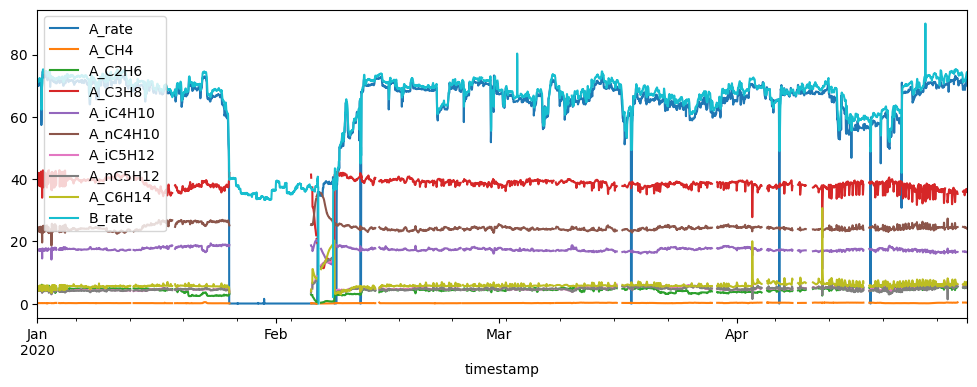

In [11]:
df_tr.plot(figsize=(12,4))

<Axes: xlabel='timestamp'>

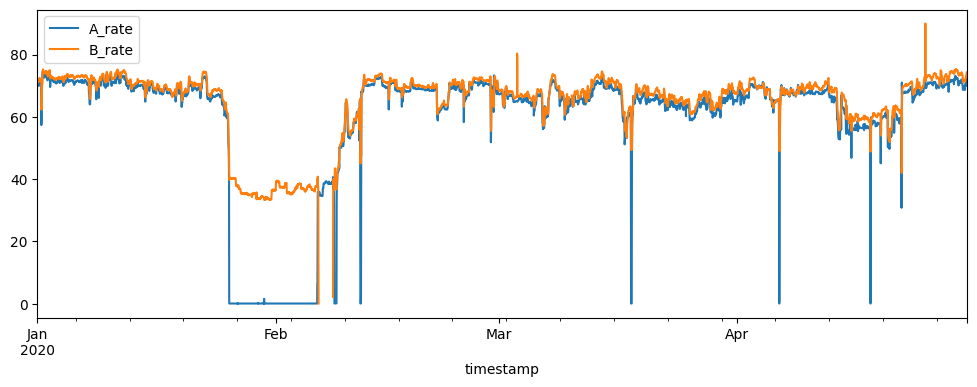

In [5]:
df_tr[['A_rate', 'B_rate']].plot(figsize=(12, 4))

In [18]:

df_sb.columns
df_tg.columns

Index(['timestamp', 'B_C2H6', 'B_C3H8', 'B_iC4H10', 'B_nC4H10'], dtype='object')

In [6]:
df_tr

,A_rate,A_CH4,A_C2H6,A_C3H8,A_iC4H10,A_nC4H10,A_iC5H12,A_nC5H12,A_C6H14,B_rate
timestamp,,,,,,,,,,
2020-01-01 00:00:00,70.855017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.982789
2020-01-01 00:30:00,70.826582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.965098
2020-01-01 01:00:00,70.809637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.867409
2020-01-01 01:30:00,69.994748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.839126
2020-01-01 02:00:00,70.072762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.336921
...,...,...,...,...,...,...,...,...,...,...
2020-04-30 21:30:00,72.009730,0.284151,4.936343,35.758852,16.473834,24.318968,6.069360,5.527463,6.577563,74.183355
2020-04-30 22:00:00,71.854180,0.282501,4.960453,35.877193,16.448487,24.074193,5.981357,5.407256,6.915378,74.213066
2020-04-30 22:30:00,71.783273,0.277686,5.013878,36.271557,16.500147,24.010123,5.829363,5.160329,6.884173,74.144367
